In [1]:
import warnings
warnings.filterwarnings('ignore')  #suppress some warnings about future code changes

import netCDF4 as nc
import xarray as xr    
import numpy as np
import datetime          #https://docs.python.org/3/library/datetime.html
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.signal as sg  #Package for signal analysis
import scipy.ndimage as si #Another package for signal analysis
#from scipy.interpolate import interp1d  #for converting cell to grid-centered coordinates
#from scipy import stats    #Used for 2D binned statistics
#from mpl_toolkits.axes_grid1 import make_axes_locatable #For plotting interior colobars
#import cartopy.crs as ccrs

from multitaper import MTSpec  #using German Prieto's multitaper package, https://github.com/gaprieto/multitaper
from scipy import fft as spfft
from scipy.fft import fft 
from scipy.stats import chi2
from scipy.special import digamma
#function for coverting Matlab's datenum into Python's datetime
#from https://gist.github.com/victorkristof/b9d794fe1ed12e708b9d
#with modifications to support array input and output
def datenum_to_datetime(datenum):
    """
    Convert Matlab datenum into Python datetime.
    
    Args:
        datenum: Date in datenum format
        
    Returns:
        Datetime object corresponding to datenum.
    """
    date=[]
    for day in datenum:
        date.append(datetime.datetime.fromordinal(int(day)) \
           + datetime.timedelta(days=day%1) \
           - datetime.timedelta(days=366))
    date=np.array(date)
    return date

plt.rcParams["figure.figsize"] = (10,6.5) #set default figure size
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'serif'

In [2]:
data_dir = "../"
filename = "snap.cdf"
ds = xr.open_dataset(data_dir+filename)
print(ds)

<xarray.Dataset> Size: 488GB
Dimensions:  (Time: 480, z: 200, y: 252, x: 504)
Coordinates:
  * x        (x) float64 4kB 0.0 1.984e+03 3.968e+03 ... 9.96e+05 9.98e+05
  * y        (y) float64 2kB 0.0 1.984e+03 3.968e+03 ... 4.96e+05 4.98e+05
  * z        (z) float64 2kB 0.0 20.0 40.0 60.0 ... 3.94e+03 3.96e+03 3.98e+03
  * Time     (Time) float64 4kB 0.0 3.6e+03 7.2e+03 ... 1.721e+06 1.724e+06
Data variables:
    u        (Time, z, y, x) float64 98GB ...
    v        (Time, z, y, x) float64 98GB ...
    w        (Time, z, y, x) float64 98GB ...
    b        (Time, z, y, x) float64 98GB ...
    p        (Time, z, y, x) float64 98GB ...
Attributes:
    dx:       1984.126984126984
    dy:       1984.126984126984
    dz:       20.0
    N0:       0.0029999999242136255
    f0:       9.999999747378752e-05
    Ro:       1.0
    dsqr:     1.0


In [3]:
import numpy as np
from scipy import signal
import gc
field_data_surface = ds['u'][:,0,:,:]  # shape (480, 252, 504)
field_data_surface

<xarray.DataArray 'u' (Time: 480, y: 252, x: 504)> Size: 488MB
[60963840 values with dtype=float64]
Coordinates:
  * x        (x) float64 4kB 0.0 1.984e+03 3.968e+03 ... 9.96e+05 9.98e+05
  * y        (y) float64 2kB 0.0 1.984e+03 3.968e+03 ... 4.96e+05 4.98e+05
    z        float64 8B 0.0
  * Time     (Time) float64 4kB 0.0 3.6e+03 7.2e+03 ... 1.721e+06 1.724e+06
Attributes:
    long_name:  velocity
    unit:       m/s

Processing 3D data shape: (480, 252, 504)
Time series shape: (480,)


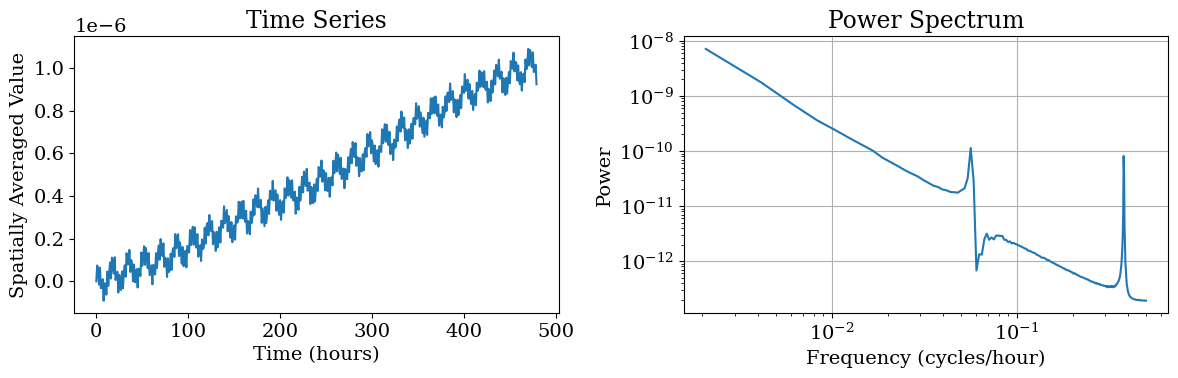

In [6]:
field_data = field_data_surface
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

def analyze_surface_spectrum(data_3d, dt=1.0, method='fft'):
    """
    Analyze frequency spectrum of 3D surface data (Time, y, x)
    
    Parameters:
    - data_3d: shape (Time, y, x)
    - dt: time step in hours (default 1.0)
    - method: 'fft' or 'welch'
    """
    print(f"Processing 3D data shape: {data_3d.shape}")
    
    # Step 1: Spatial averaging (much faster now with 3D)
    time_series = np.mean(data_3d, axis=(1, 2))  # Average over y,x dimensions
    print(f"Time series shape: {time_series.shape}")
    
    # Step 2: Frequency analysis
    if method == 'fft':
        freqs = np.fft.fftfreq(len(time_series), d=dt)
        spectrum = np.abs(np.fft.fft(time_series))**2
        
        # Keep only positive frequencies
        pos_mask = freqs > 0
        freqs = freqs[pos_mask]
        spectrum = spectrum[pos_mask]
        
    elif method == 'welch':
        # Better for noisy data
        freqs, spectrum = signal.welch(time_series, fs=1/dt, nperseg=min(128, len(time_series)//4))
    
    return freqs, spectrum, time_series

# Usage
freqs, spectrum, ts = analyze_surface_spectrum(field_data, dt=1.0)

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(ts)
plt.xlabel('Time (hours)')
plt.ylabel('Spatially Averaged Value')
plt.title('Time Series')

plt.subplot(1, 2, 2)
plt.loglog(freqs, spectrum)
plt.xlabel('Frequency (cycles/hour)')
plt.ylabel('Power')
plt.title('Power Spectrum')
plt.grid(True)

plt.tight_layout()
plt.show()


Found 0 peaks:
Peak #  Frequency (cyc/h)  Period (hours)  Period (days)  Power
-----------------------------------------------------------------


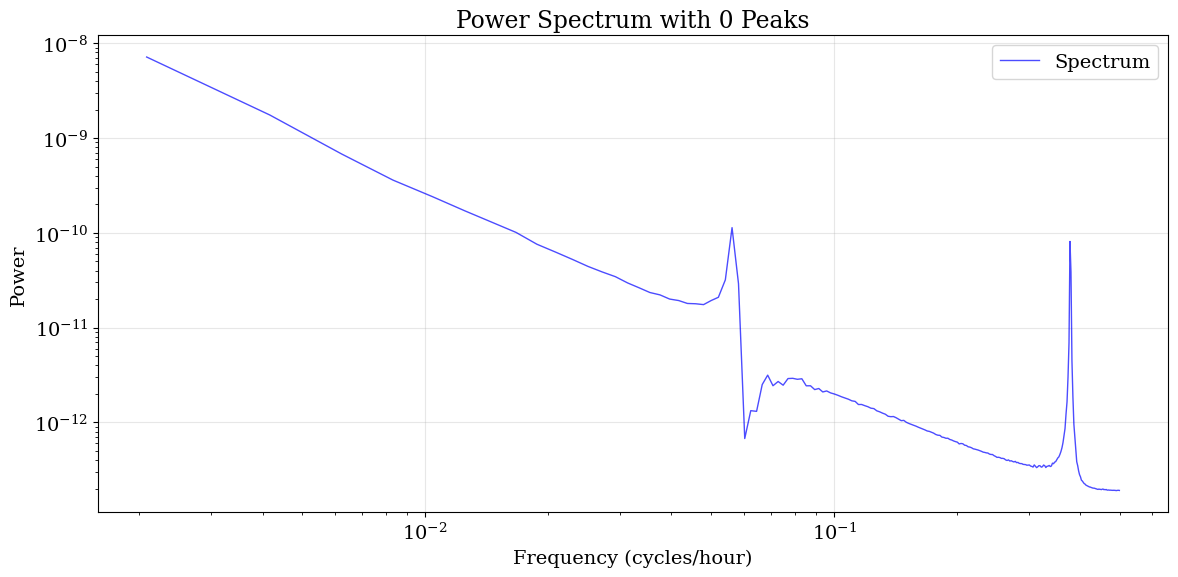

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def plot_spectrum_with_peaks(freqs, spectrum, height_threshold=0.1, prominence=None, distance=None):
    """
    Plot spectrum with vertical lines at peaks
    
    Parameters:
    - freqs, spectrum: your frequency analysis results
    - height_threshold: minimum peak height as fraction of max (0.1 = 10% of max)
    - prominence: minimum prominence of peaks (None = auto)
    - distance: minimum distance between peaks in samples (None = auto)
    """
    
    # Find peaks
    if prominence is None:
        prominence = np.max(spectrum) * 0.05  # 5% of max as default prominence
    
    peaks, properties = find_peaks(
        spectrum, 
        height=np.max(spectrum) * height_threshold,
        prominence=prominence,
        distance=distance
    )
    
    # Plot spectrum
    plt.figure(figsize=(12, 6))
    plt.loglog(freqs, spectrum, 'b-', linewidth=1, alpha=0.7, label='Spectrum')
    
    # Add vertical lines at peaks
    peak_freqs = freqs[peaks]
    peak_values = spectrum[peaks]
    
    for i, (freq, value) in enumerate(zip(peak_freqs, peak_values)):
        plt.axvline(freq, color='red', linestyle='--', alpha=0.7)
        
        # Convert frequency to period for labeling
        period_hours = 1.0 / freq
        period_days = period_hours / 24
        
        # Label the peak
        if period_days >= 1:
            label = f'{period_days:.1f}d'
        else:
            label = f'{period_hours:.1f}h'
            
        plt.text(freq, value, label, rotation=90, 
                verticalalignment='bottom', horizontalalignment='right',
                fontsize=9, color='red')
    
    plt.xlabel('Frequency (cycles/hour)')
    plt.ylabel('Power')
    plt.title(f'Power Spectrum with {len(peaks)} Peaks')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Print peak information
    print(f"\nFound {len(peaks)} peaks:")
    print("Peak #  Frequency (cyc/h)  Period (hours)  Period (days)  Power")
    print("-" * 65)
    
    for i, (peak_idx, freq, value) in enumerate(zip(peaks, peak_freqs, peak_values)):
        period_hours = 1.0 / freq
        period_days = period_hours / 24
        print(f"{i+1:4d}    {freq:8.4f}        {period_hours:8.1f}      {period_days:8.2f}    {value:.2e}")
    
    plt.tight_layout()
    plt.show()
    
    return peaks, peak_freqs, peak_values

# Usage with your data
peaks, peak_freqs, peak_values = plot_spectrum_with_peaks(freqs, spectrum)

In [9]:
def extract_peak_info(freqs, spectrum, peaks):
    """
    Extract detailed information about peaks
    """
    peak_data = []
    
    for i, peak_idx in enumerate(peaks):
        freq = freqs[peak_idx]
        power = spectrum[peak_idx]
        period_hours = 1.0 / freq
        period_days = period_hours / 24
        
        # Classify the peak
        if 0.9 < period_days < 1.1:  # ~24 hours
            peak_type = "Daily cycle"
        elif 0.45 < period_days < 0.55:  # ~12 hours
            peak_type = "Semi-daily"
        elif period_days > 5:
            peak_type = "Long-term variation"
        elif period_days < 0.25:  # < 6 hours
            peak_type = "High-frequency"
        else:
            peak_type = "Multi-day cycle"
        
        peak_data.append({
            'peak_number': i+1,
            'frequency': freq,
            'period_hours': period_hours,
            'period_days': period_days,
            'power': power,
            'type': peak_type
        })
    
    return peak_data

# Get detailed peak information
peak_info = extract_peak_info(freqs, spectrum, peaks)

# Print formatted table
print("\nDetailed Peak Analysis:")
print("=" * 80)
for info in peak_info:
    print(f"Peak {info['peak_number']}: {info['type']}")
    print(f"  Frequency: {info['frequency']:.4f} cycles/hour")
    print(f"  Period: {info['period_hours']:.1f} hours ({info['period_days']:.2f} days)")
    print(f"  Power: {info['power']:.2e}")
    print()


Detailed Peak Analysis:


Method 1 (1% height): 2 peaks
Method 2 (2% prominence): 0 peaks
Method 3 (all local maxima): 37 peaks
Method 4 (log space): 2 peaks


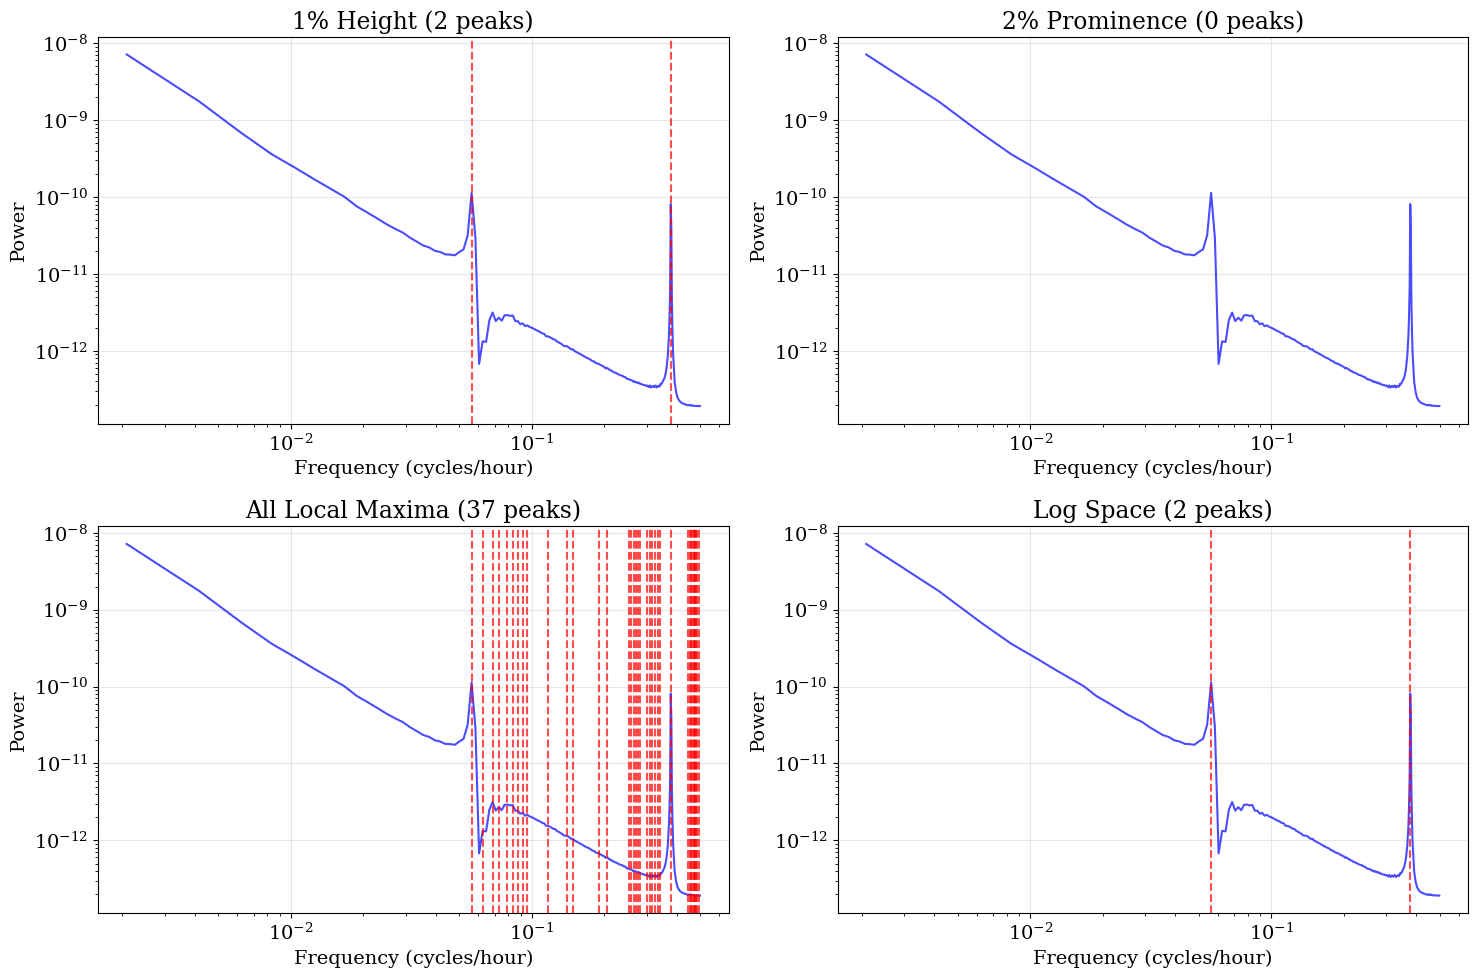

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def sensitive_peak_detection(freqs, spectrum):
    """
    More sensitive peak detection with multiple methods
    """
    
    # Method 1: Very low threshold
    peaks1, _ = find_peaks(spectrum, height=np.max(spectrum) * 0.01)  # 1% of max
    
    # Method 2: Use prominence instead of height
    peaks2, _ = find_peaks(spectrum, prominence=np.max(spectrum) * 0.02)  # 2% prominence
    
    # Method 3: No height requirement, just local maxima
    peaks3, _ = find_peaks(spectrum)
    
    # Method 4: Find peaks in log space (sometimes better for broad peaks)
    log_spectrum = np.log10(spectrum + 1e-10)  # Avoid log(0)
    peaks4, _ = find_peaks(log_spectrum, prominence=0.1)
    
    print(f"Method 1 (1% height): {len(peaks1)} peaks")
    print(f"Method 2 (2% prominence): {len(peaks2)} peaks") 
    print(f"Method 3 (all local maxima): {len(peaks3)} peaks")
    print(f"Method 4 (log space): {len(peaks4)} peaks")
    
    # Plot all methods
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    methods = [peaks1, peaks2, peaks3, peaks4]
    titles = ['1% Height', '2% Prominence', 'All Local Maxima', 'Log Space']
    
    for i, (peaks, title) in enumerate(zip(methods, titles)):
        ax = axes[i//2, i%2]
        ax.loglog(freqs, spectrum, 'b-', alpha=0.7)
        
        # Add vertical lines at peaks
        for peak in peaks:
            freq = freqs[peak]
            ax.axvline(freq, color='red', linestyle='--', alpha=0.7)
        
        ax.set_title(f'{title} ({len(peaks)} peaks)')
        ax.set_xlabel('Frequency (cycles/hour)')
        ax.set_ylabel('Power')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return peaks1, peaks2, peaks3, peaks4

# Try sensitive detection
p1, p2, p3, p4 = sensitive_peak_detection(freqs, spectrum)

Found 2 peaks:
Peak #  Frequency (cyc/h)  Period (hours)  Period (days)
-------------------------------------------------------
   1      0.0563            17.8          0.74
   2      0.3771             2.7          0.11


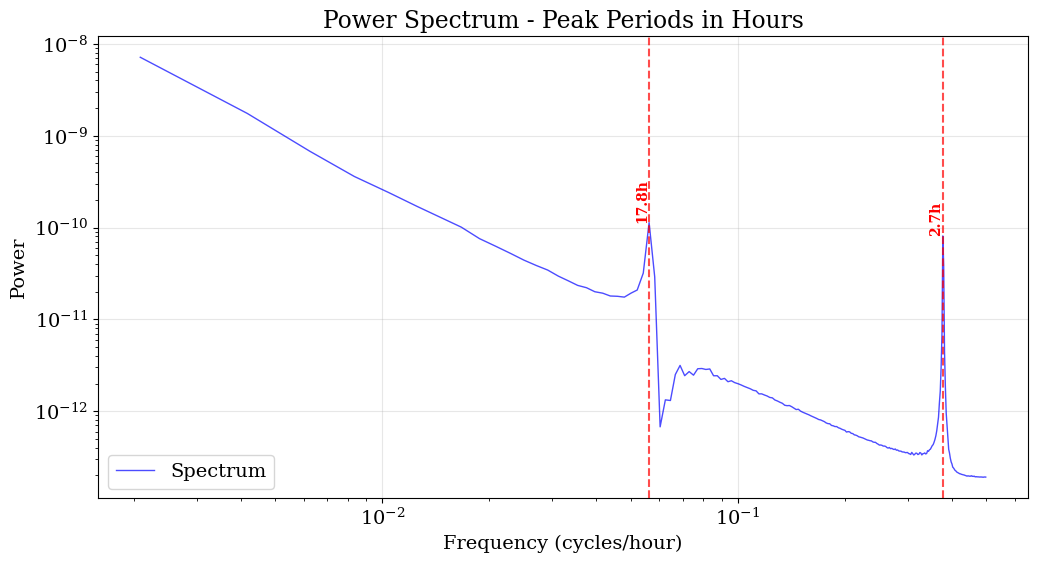


Your 2 peak periods are: [np.float64(17.77777777777778), np.float64(2.6519337016574585)] hours
Which corresponds to: [np.float64(0.7407407407407408), np.float64(0.11049723756906077)] days


In [11]:
def extract_peak_periods(freqs, spectrum, peaks):
    """
    Extract peak frequencies and convert to periods in hours
    """
    print(f"Found {len(peaks)} peaks:")
    print("Peak #  Frequency (cyc/h)  Period (hours)  Period (days)")
    print("-" * 55)
    
    peak_data = []
    
    for i, peak_idx in enumerate(peaks):
        freq = freqs[peak_idx]
        power = spectrum[peak_idx]
        period_hours = 1.0 / freq  # Convert frequency to period in hours
        period_days = period_hours / 24
        
        print(f"{i+1:4d}    {freq:8.4f}        {period_hours:8.1f}      {period_days:8.2f}")
        
        peak_data.append({
            'peak_number': i+1,
            'frequency_cyc_per_hour': freq,
            'period_hours': period_hours,
            'period_days': period_days,
            'power': power
        })
    
    return peak_data

# Using your 1% height peaks from before
peaks_1pct, _ = find_peaks(spectrum, height=np.max(spectrum) * 0.01)
peak_info = extract_peak_periods(freqs, spectrum, peaks_1pct)

# Plot with period labels
plt.figure(figsize=(12, 6))
plt.loglog(freqs, spectrum, 'b-', linewidth=1, alpha=0.7, label='Spectrum')

for i, peak_idx in enumerate(peaks_1pct):
    freq = freqs[peak_idx]
    power = spectrum[peak_idx]
    period_hours = 1.0 / freq
    
    # Add vertical line
    plt.axvline(freq, color='red', linestyle='--', alpha=0.7)
    
    # Label with period in hours
    plt.text(freq, power, f'{period_hours:.1f}h', rotation=90, 
             verticalalignment='bottom', horizontalalignment='right',
             fontsize=10, color='red', fontweight='bold')

plt.xlabel('Frequency (cycles/hour)')
plt.ylabel('Power')
plt.title('Power Spectrum - Peak Periods in Hours')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Extract just the periods in hours
peak_periods_hours = [info['period_hours'] for info in peak_info]
print(f"\nYour 2 peak periods are: {peak_periods_hours} hours")
print(f"Which corresponds to: {[p/24 for p in peak_periods_hours]} days")